In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import json
from youtube_api_helper import * #please import utils.py. (It includes code to fetch data from YouTube API)
from IPython.display import Image, display

base = "~/Desktop/from_old_notebook/adaproject/ADA_P3/"

In [2]:
## import os
os.environ["YT_API_KEY"] = "YOUR API KEY"
# https://console.cloud.google.com/apis/api/youtube.googleapis.com/metrics?project=totake1st
API_KEY = os.getenv("YT_API_KEY") or globals().get("API_KEY", "")

## Channel Activity Status from YouTube API (2025)


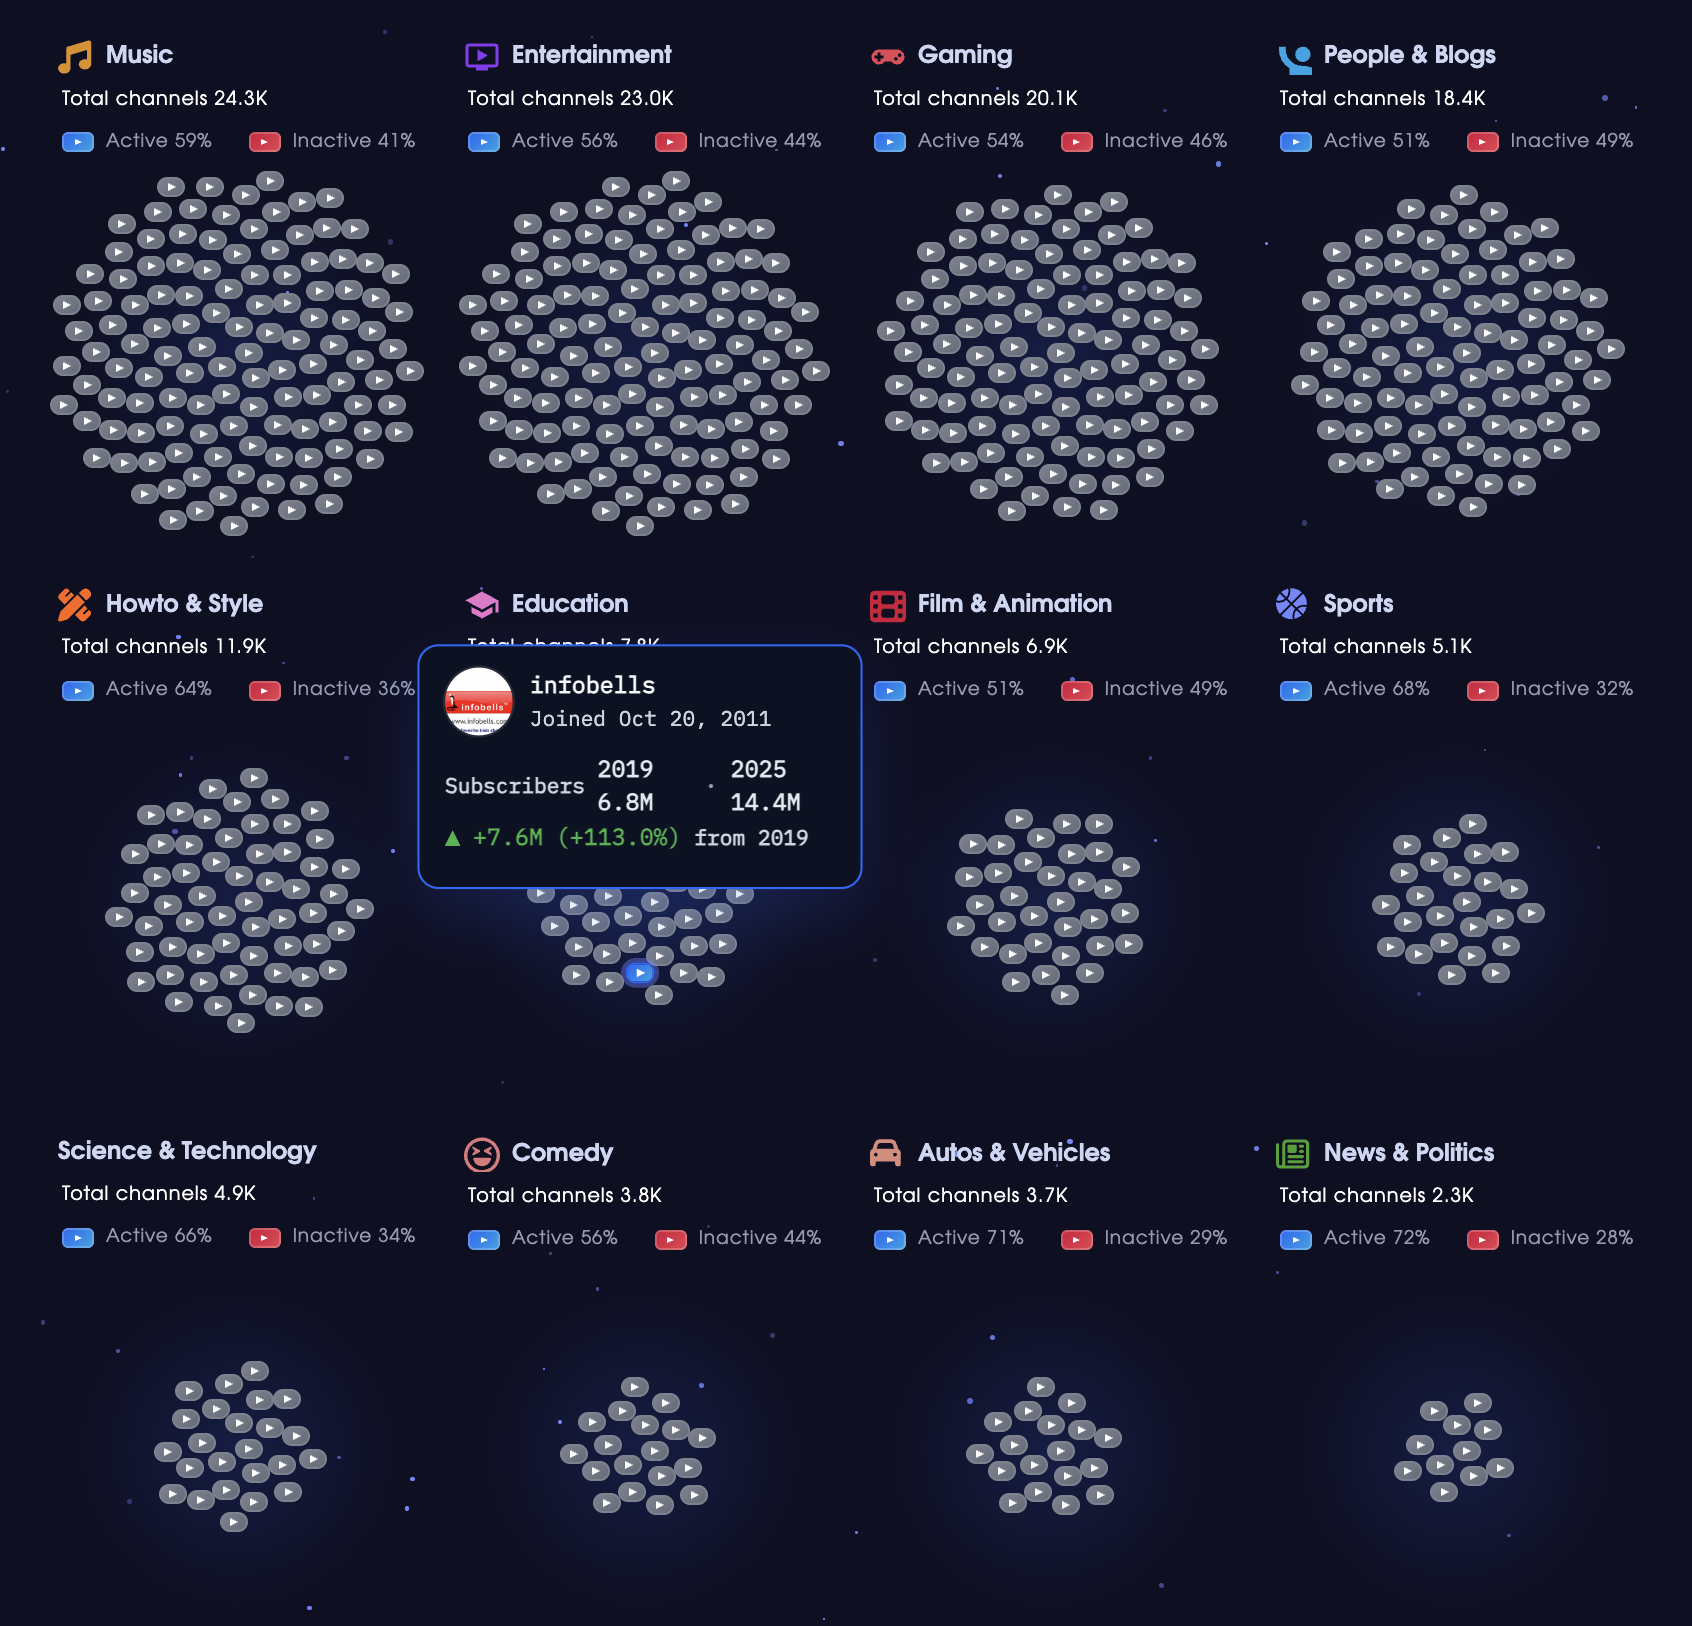

In [3]:
display(Image(filename="images/api_activity.png"))

![API activity](https://github.com/epfl-ada/ada-2025-project-shenanigans/blob/ender/ADA_P3/images/api_activity.png?raw=true)

**Figure 1.** Channel activity status based on YouTube Data API v3 enrichment.  
Channel-level metadata (e.g., subscriber count and most recent upload) is retrieved via the YouTube API and used to classify channels as active or inactive in 2025. Historical analyses in this notebook rely exclusively on the YouNiverse dataset; API-based enrichment is used only for current status and descriptive context.


# YouTube Enrichment Utilities (Resumable)

Channel-level data is sourced from the *YouNiverse* dataset and enriched with up-to-date metadata from the YouTube Data API v3.

This notebook documents a reusable and **resumable** utility pipeline that enriches a DataFrame of YouTube channels with current channel-level information obtained from the YouTube Data API v3.

The pipeline starts from a minimal input—a column containing channel IDs or channel URLs—and produces an enriched DataFrame containing:
- Current channel-level statistics (subscriber count, total views, video count)
- Channel identity information (title and avatar)
- The most recent upload per channel
- A simple, reproducible activity classification for a given year

The implementation is designed to scale to large datasets (100k+ channels) while remaining robust to API quota limits and interruptions.


## Imports and configuration

We import standard libraries for data processing, HTTP requests, concurrency, and filesystem-based caching.  
We also load the API key from `YT_API_KEY` (preferred) or a notebook variable `API_KEY`.

```python
import os, re, time, json
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import requests

API_KEY = os.getenv("YT_API_KEY") or globals().get("API_KEY", "")

BASE = "https://www.googleapis.com/youtube/v3"
CH_ID_RE = re.compile(r"^UC[A-Za-z0-9_-]{20,}$")
URL_CH_RE = re.compile(r"(?:https?://)?(?:www\.)?youtube\.com/channel/([^/?#]+)", re.I)


## Helper constants

Constants used for activity normalization and representative sampling.

```python
UNIT_DEFAULT = 200
DEFAULT_ACTIVITY_MAPPING = {
    "inactive": "not_active",
    "Not Available": "not_active",
}



## `normalize_activity_band(df: pd.DataFrame) -> pd.DataFrame`

Normalizes channel activity labels to ensure consistent downstream aggregation and visualization.

This function:
- Uses `activity_band_2025` if present; otherwise expects `activity_band`
- Standardizes values (string conversion, whitespace stripping, lowercasing)
- Maps known aliases (e.g. `"inactive"`, `"Not Available"`) to canonical labels via `DEFAULT_ACTIVITY_MAPPING`

```python
def normalize_activity_band(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "activity_band_2025" in df.columns:
        df["activity_band"] = df["activity_band_2025"]
    elif "activity_band" not in df.columns:
        raise ValueError("need activity_band or activity_band_2025")

    df["activity_band"] = (
        df["activity_band"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(DEFAULT_ACTIVITY_MAPPING)
    )
    return df


## `validate_activity_inputs(df: pd.DataFrame) -> None`

Validates that the DataFrame contains all columns required for category-level aggregation and visualization/export.

Required columns:
- `category_cc`
- `activity_band`
- `url`
- `subscribers_cc`

Raises a `ValueError` if any required column is missing.

```python
def validate_activity_inputs(df: pd.DataFrame) -> None:
    required = ["category_cc", "activity_band", "url", "subscribers_cc"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"df missing columns: {missing}")


## `make_category_counts(df_cat: pd.DataFrame, cat_id: str, label: str) -> dict`

Computes the number of active and inactive channels within a single category.

- Uses `value_counts()` on `activity_band`
- Returns a compact dictionary optimized for JSON-based visualization layers

```python
def make_category_counts(df_cat: pd.DataFrame, cat_id: str, label: str) -> dict:
    counts = df_cat["activity_band"].value_counts(dropna=False)
    return {
        "id": cat_id,
        "label": label,
        "active": int(counts.get("active", 0)),
        "not_active": int(counts.get("not_active", 0)),
    }


## `sample_representative_links(df_cat: pd.DataFrame, *, unit: int, keep_fields: list[str]) -> dict`

Selects representative channels per category and activity band for interactive examples.

This function:
- Converts raw counts into a number of samples using `round(count / unit)`
- For each band (`active`, `not_active`), selects the most-subscribed channels (`subscribers_cc`)
- Keeps only selected fields (`keep_fields`) for lightweight export

Returns:
- `{"active": [...], "not_active": [...]}` lists of row-level dictionaries

```python
def sample_representative_links(
    df_cat: pd.DataFrame,
    *,
    unit: int,
    keep_fields: list[str],
) -> dict:
    counts = df_cat["activity_band"].value_counts(dropna=False)

    n_icons = {
        band: int(round(counts.get(band, 0) / unit))
        for band in ["active", "not_active"]
    }

    out = {"active": [], "not_active": []}

    for band, n in n_icons.items():
        if n <= 0:
            continue

        picked = (
            df_cat[df_cat["activity_band"] == band]
            .sort_values("subscribers_cc", ascending=False)
            .head(n)
        )

        out[band] = [
            {k: r.get(k) for k in keep_fields}
            | {
                "url": r.get("url"),
                "category_cc": r.get("category_cc"),
            }
            for _, r in picked.iterrows()
        ]

    return out

## `no_data() -> str`

Returns the canonical missing-data label (`"Not Available"`).

Centralizing this value avoids inconsistent missing-data handling across the pipeline.

```python
def no_data() -> str:
    return "Not Available"


## `channel_id_from_any(x)`

Extracts a canonical YouTube channel ID from heterogeneous inputs.

- Accepts raw channel IDs (`UC…`) or full channel URLs
- Uses regex patterns to detect and extract valid IDs
- Returns `None` if extraction fails

This normalization step enables consistent caching and API calls.

```python
def channel_id_from_any(x):
    if x is None:
        return None
    s = str(x).strip()
    if CH_ID_RE.match(s):
        return s
    m = URL_CH_RE.search(s)
    return m.group(1) if m else None


## `channel_url(cid: str) -> str`

Constructs a canonical YouTube channel URL from a channel ID.

```python
def channel_url(cid: str) -> str:
    return f"https://www.youtube.com/channel/{cid}"


## `classify_activity_from_last_upload(last_upload_iso: str | None, year: int) -> str`

Assigns an activity label based on the year of the most recent upload.

Rules:
- If the most recent upload year equals the target year → `active`
- If it differs → `inactive`
- If upload information is missing or malformed → `"Not Available"`

This definition captures “uploaded at least once during the year” using a transparent rule.

```python
def classify_activity_from_last_upload(last_upload_iso: str | None, year: int) -> str:
    if not last_upload_iso or last_upload_iso == no_data():
        return no_data()
    try:
        y = int(str(last_upload_iso)[:4])
        return "active" if y == year else "inactive"
    except Exception:
        return no_data()


## `is_quota_error(err: Exception) -> bool`

Detects whether an exception likely corresponds to a YouTube API quota or rate-limit error.

- Matches common quota-related substrings in error messages
- Used to stop execution safely while preserving cached progress

```python
def is_quota_error(err: Exception) -> bool:
    s = str(err).lower()
    return any(k in s for k in [
        "quotaexceeded",
        "dailylimitexceeded",
        "userratelimitexceeded",
        "ratelimitexceeded",
        "exceeded your quota",
    ])


## `yt_get(endpoint: str, params: dict, session: requests.Session, timeout=20, retries=5)`

Robust wrapper around YouTube API GET requests.

This function:
- Injects the API key automatically
- Retries transient failures (`429`, `500`, `503`) with backoff
- Raises informative errors for non-recoverable HTTP responses

This improves stability during long-running enrichment jobs.

```python
def yt_get(endpoint: str, params: dict, session: requests.Session, timeout=20, retries=5):
    url = f"{BASE}/{endpoint}"
    params = dict(params)
    params["key"] = API_KEY

    last_err = None
    for attempt in range(retries):
        try:
            r = session.get(url, params=params, timeout=timeout)
            if r.status_code == 200:
                return r.json()

            if r.status_code in (429, 500, 503):
                time.sleep(1.5 * (attempt + 1))
                continue

            last_err = RuntimeError(f"HTTP {r.status_code}: {r.text}")
            raise last_err

        except Exception as e:
            last_err = e
            time.sleep(1.0 * (attempt + 1))

    raise last_err


# API fetch functions

The enrichment logic uses three API stages:
1. `channels.list` (batched): fetch channel metadata + uploads playlist id  
2. `playlistItems.list` (per channel, concurrent): fetch most recent video id  
3. `videos.list` (batched): fetch published date + title of most recent video


## `fetch_channels_core(channel_ids: list[str], session: requests.Session) -> dict[str, dict]`

Fetches channel-level metadata using the `channels.list` endpoint.

- Processes channel IDs in batches of 50 (API limit)
- Extracts identity, statistics, and uploads playlist ID
- Marks channels not returned by the API as `has_api = False`

Outputs a dictionary keyed by channel ID with the core channel fields.

```python
def fetch_channels_core(channel_ids: list[str], session: requests.Session) -> dict[str, dict]:
    out = {}
    ids = pd.Series(channel_ids).dropna().astype(str).unique().tolist()

    def to_int(x):
        try:
            return int(x)
        except Exception:
            return None

    for i in range(0, len(ids), 50):
        chunk = ids[i:i+50]
        data = yt_get(
            "channels",
            {"part": "snippet,statistics,contentDetails", "id": ",".join(chunk), "maxResults": 50},
            session=session,
        )
        items = {it["id"]: it for it in data.get("items", [])}

        for cid in chunk:
            it = items.get(cid)
            if not it:
                out[cid] = {"has_api": False}
                continue

            sn = it.get("snippet") or {}
            st = it.get("statistics") or {}
            cd = it.get("contentDetails") or {}
            uploads = ((cd.get("relatedPlaylists") or {}).get("uploads"))

            thumbs = sn.get("thumbnails") or {}
            avatar = (
                (thumbs.get("high") or {}).get("url")
                or (thumbs.get("medium") or {}).get("url")
                or (thumbs.get("default") or {}).get("url")
            )

            out[cid] = {
                "has_api": True,
                "channel_title_2025": sn.get("title"),
                "channel_avatar_url_2025": avatar,
                "subscriber_count_2025": to_int(st.get("subscriberCount")),
                "video_count_2025": to_int(st.get("videoCount")),
                "view_count_2025": to_int(st.get("viewCount")),
                "uploads_playlist_id": uploads,
            }

        time.sleep(0.02)

    return out


## `_fetch_latest_video_id_one(uploads_pid: str, session: requests.Session) -> tuple[str | None, str | None]`

Retrieves the most recent video from a channel’s uploads playlist.

- Calls `playlistItems.list` with `maxResults=1`
- Returns `(videoId, title)` if available
- Returns `(None, None)` if the playlist is empty or unavailable

This is a single-channel helper used by the concurrent wrapper.

```python
def _fetch_latest_video_id_one(uploads_pid: str, session: requests.Session) -> tuple[str | None, str | None]:
    data = yt_get(
        "playlistItems",
        {"part": "contentDetails,snippet", "playlistId": uploads_pid, "maxResults": 1},
        session=session,
    )
    items = data.get("items") or []
    if not items:
        return None, None
    it = items[0]
    cd = it.get("contentDetails") or {}
    sn = it.get("snippet") or {}
    return cd.get("videoId"), sn.get("title")


## `fetch_latest_video_ids_concurrent(core_map: dict[str, dict], session: requests.Session, max_workers=15) -> dict[str, dict]`

Fetches latest video IDs for all channels concurrently.

- Submits one request per channel (only if `has_api=True` and `uploads_playlist_id` exists)
- Uses a thread pool to reduce runtime
- Handles per-channel failures gracefully (missing video id instead of crashing)

Returns a dictionary keyed by channel ID containing:
- `latest_video_id`
- `last_video_title_2025` (best-effort)

```python
def fetch_latest_video_ids_concurrent(core_map: dict[str, dict], session: requests.Session, max_workers=15) -> dict[str, dict]:
    out = {cid: {"latest_video_id": None, "last_video_title_2025": None} for cid in core_map.keys()}

    tasks = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for cid, info in core_map.items():
            pid = info.get("uploads_playlist_id")
            if not info.get("has_api") or not pid:
                continue
            tasks.append((cid, ex.submit(_fetch_latest_video_id_one, pid, session)))

        for cid, fut in tasks:
            try:
                vid, title = fut.result()
                out[cid] = {"latest_video_id": vid, "last_video_title_2025": title}
            except Exception:
                out[cid] = {"latest_video_id": None, "last_video_title_2025": None}

    return out


## `fetch_videos_snippet(video_ids: list[str], session: requests.Session) -> dict[str, dict]`

Retrieves authoritative metadata for videos using the `videos.list` endpoint.

- Processes video IDs in batches of 50
- Extracts `publishedAt` and `title`
- Enables reliable activity classification using the publish date

Returns a dictionary keyed by video ID with snippet fields.

```python
def fetch_videos_snippet(video_ids: list[str], session: requests.Session) -> dict[str, dict]:
    out = {}
    vids = pd.Series(video_ids).dropna().astype(str).unique().tolist()

    for i in range(0, len(vids), 50):
        chunk = vids[i:i+50]
        data = yt_get(
            "videos",
            {"part": "snippet", "id": ",".join(chunk), "maxResults": 50},
            session=session,
        )
        for it in (data.get("items") or []):
            vid = it.get("id")
            sn = it.get("snippet") or {}
            out[vid] = {"publishedAt": sn.get("publishedAt"), "title": sn.get("title")}
        time.sleep(0.02)

    return out


# Parquet cache helpers

To support resumability under quota constraints, enrichment results are stored in a local parquet cache.
The join key is `_channel_id_norm` (one row per channel).


## `_cache_path(cache_dir: str | Path) -> Path`

Creates the cache directory if needed and returns the full path to the parquet cache file.

```python
def _cache_path(cache_dir: str | Path) -> Path:
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / "yt_enrichment_cache.parquet"


## `load_cache_parquet(cache_dir: str | Path) -> pd.DataFrame`

Loads cached enrichment results from parquet.

- If no cache exists, returns an empty DataFrame
- The cache is expected to include `_channel_id_norm` as the unique key

```python
def load_cache_parquet(cache_dir: str | Path) -> pd.DataFrame:
    path = _cache_path(cache_dir)
    if not path.exists():
        return pd.DataFrame()
    return pd.read_parquet(path)


## `upsert_cache_parquet(cache_dir: str | Path, new_rows: pd.DataFrame) -> None`

Writes new enrichment results to the parquet cache.

- If the cache exists, appends and then deduplicates on `_channel_id_norm`
- Keeps the most recent entry per channel

This enables safe resumption after interrupts or quota exhaustion.

```python
def upsert_cache_parquet(cache_dir: str | Path, new_rows: pd.DataFrame) -> None:
    path = _cache_path(cache_dir)
    if new_rows.empty:
        return

    if path.exists():
        old = pd.read_parquet(path)
        combined = pd.concat([old, new_rows], ignore_index=True)
        combined = combined.drop_duplicates(subset=["_channel_id_norm"], keep="last")
    else:
        combined = new_rows.drop_duplicates(subset=["_channel_id_norm"], keep="last")

    combined.to_parquet(path, index=False)


# Main function

The function below exposes the full enrichment pipeline through a single, resumable interface.

High-level flow:
1. Normalize channel identifiers into `_channel_id_norm`
2. Load cache and skip already processed channels
3. Process remaining channels in chunks
4. Fetch channel metadata (batched)
5. Fetch latest upload video IDs (concurrent)
6. Fetch latest video snippets (batched)
7. Classify activity based on publish year
8. Upsert chunk results into parquet cache
9. Merge cached results back into the original DataFrame


## `extend_df_with_youtube_fetch_resumable_parquet(...) -> pd.DataFrame`

Enriches a DataFrame of YouTube channels with current metadata, using a parquet cache for resumability.

Parameters:
- `df`: input DataFrame
- `channel_col`: column containing channel IDs or channel URLs
- `year`: activity classification target year (e.g., 2025)
- `max_workers`: number of threads for per-channel playlist requests
- `cache_dir`: folder for parquet cache
- `resume`: whether to load and reuse cached results
- `chunk_size_channels`: how many channels to process per chunk

Returns:
- A copy of the input DataFrame with enrichment columns merged in.

```python
def extend_df_with_youtube_fetch_resumable_parquet(
    df: pd.DataFrame,
    channel_col: str,
    year: int,
    max_workers: int = 15,
    cache_dir: str | Path = "cache/yt_parquet",
    resume: bool = True,
    chunk_size_channels: int = 2000,
) -> pd.DataFrame:
    if channel_col not in df.columns:
        raise ValueError(f"df missing channel column: {channel_col}")

    df_ext = df.copy()
    df_ext["_channel_id_norm"] = df_ext[channel_col].map(channel_id_from_any)

    ids_all = (
        pd.Series(df_ext["_channel_id_norm"])
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    if len(ids_all) == 0:
        raise ValueError("Could not parse any channel ids from your channel column.")

    cached_df = load_cache_parquet(cache_dir) if resume else pd.DataFrame()
    cached_ids = set(cached_df["_channel_id_norm"].astype(str).tolist()) if (resume and not cached_df.empty and "_channel_id_norm" in cached_df.columns) else set()

    remaining = [cid for cid in ids_all if cid not in cached_ids]
    print(f"total channels: {len(ids_all):,} | cached: {len(cached_ids):,} | remaining: {len(remaining):,}")

    fetched_at = datetime.now(timezone.utc).isoformat()
    fetched_rows_all = []

    with requests.Session() as session:
        for start in range(0, len(remaining), chunk_size_channels):
            chunk_ids = remaining[start:start + chunk_size_channels]
            print(f"processing chunk {start//chunk_size_channels + 1} | channels={len(chunk_ids):,}")

            try:
                core = fetch_channels_core(chunk_ids, session=session)
                latest_vids = fetch_latest_video_ids_concurrent(core, session=session, max_workers=max_workers)

                all_video_ids = [v["latest_video_id"] for v in latest_vids.values() if v.get("latest_video_id")]
                video_sn = fetch_videos_snippet(all_video_ids, session=session) if all_video_ids else {}

            except Exception as e:
                if is_quota_error(e):
                    print("stopping early due to quota/rate limit. progress is saved in parquet cache.")
                    break
                raise

            rows = []
            for cid in chunk_ids:
                info = dict(core.get(cid, {}) or {})
                lv = dict(latest_vids.get(cid, {}) or {})

                has_api = bool(info.get("has_api"))
                latest_video_id = lv.get("latest_video_id")

                published_at = None
                title = lv.get("last_video_title_2025")
                if latest_video_id and latest_video_id in video_sn:
                    published_at = video_sn[latest_video_id].get("publishedAt")
                    title = video_sn[latest_video_id].get("title") or title

                activity_band = classify_activity_from_last_upload(published_at, year) if has_api else no_data()

                rows.append({
                    "_channel_id_norm": cid,
                    "url": channel_url(cid),
                    "has_api": has_api,
                    "subs_fetched_at_utc": fetched_at,

                    "channel_title_2025": info.get("channel_title_2025"),
                    "channel_avatar_url_2025": info.get("channel_avatar_url_2025"),
                    "subscriber_count_2025": info.get("subscriber_count_2025"),
                    "video_count_2025": info.get("video_count_2025"),
                    "view_count_2025": info.get("view_count_2025"),

                    "uploads_playlist_id": info.get("uploads_playlist_id"),
                    "latest_video_id": latest_video_id,

                    "last_upload_utc_2025": published_at,
                    "last_video_title_2025": title,
                    "activity_band_2025": activity_band,
                })

            new_rows = pd.DataFrame(rows)
            upsert_cache_parquet(cache_dir, new_rows)
            fetched_rows_all.append(new_rows)

    final_cache = load_cache_parquet(cache_dir) if resume else pd.concat(fetched_rows_all, ignore_index=True)
    if final_cache.empty:
        raise ValueError("no cached or fetched rows available. nothing to merge.")

    df_ext = df_ext.merge(final_cache, on="_channel_id_norm", how="left")

    fill_cols = [
        "channel_title_2025", "channel_avatar_url_2025",
        "subscriber_count_2025", "video_count_2025", "view_count_2025",
        "last_upload_utc_2025", "last_video_title_2025",
        "activity_band_2025"
    ]
    for c in fill_cols:
        if c in df_ext.columns:
            df_ext[c] = df_ext[c].where(pd.notna(df_ext[c]), no_data())

    return df_ext


# Usage

The pipeline is called via a single function:

- `df`: your input DataFrame
- `channel_col`: the column containing channel IDs or `/channel/...` URLs
- `year`: target year for activity classification (e.g., 2025)


## Example usage

```python
df_extended = extend_df_with_youtube_fetch_resumable_parquet(
    df,
    channel_col="channel",
    year=2025,
    max_workers=15,
    cache_dir="cache/yt_parquet",
    resume=True,
    chunk_size_channels=8000,
)

In [3]:
df_channels = pd.read_csv("data/df_channels_en.tsv.gz", sep="\t")

print("channels preview:", df_channels.shape)

channels preview: (136470, 8)


In [4]:
df_channels.columns.tolist()

['category_cc',
 'join_date',
 'channel',
 'name_cc',
 'subscribers_cc',
 'videos_cc',
 'subscriber_rank_sb',
 'weights']

In [5]:
df_channels.head(3)

,category_cc,join_date,channel,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,weights
0,Gaming,2010-04-29,UC-lHJZR3Gqxm24_Vd_AJ5Yw,PewDiePie,101000000,3956,3.0,2.087
1,Education,2006-09-01,UCbCmjCuTUZos6Inko4u57UQ,Cocomelon - Nursery ...,60100000,458,7.0,2.087
2,Entertainment,2006-09-20,UCpEhnqL0y41EpW2TvWAHD7Q,SET India,56018869,32661,8.0,2.087


### Running the Enrichment Pipeline (Example)

The following cell runs the YouTube Data API enrichment on the channel table.  
Starting from `df_channels` (containing channel IDs or channel URLs in the `channel` column), the function fetches current channel metadata and the most recent upload, then derives an activity label for the target year.

A local parquet cache (`cache/yt_parquet`) is used to make the process **resumable**: previously fetched channels are skipped, and interrupted runs can continue from where they stopped.  
The parameters below control concurrency (`max_workers`) and batching (`chunk_size_channels`) to balance speed and quota safety.


In [6]:
df = df_channels.copy()

RUN_FULL_COMPUTATION = False  # set to True to recompute from the raw data

if RUN_FULL_COMPUTATION:
    df_extended = extend_df_with_youtube_fetch_resumable_parquet(
        df,
        channel_col="channel",
        year=2025,
        max_workers=15,
        cache_dir="cache/yt_parquet",
        resume=True,
        chunk_size_channels=8000,
    )
else:
    df_extended = pd.read_csv("cache/yt_parquet/df_extended.csv")
    df = df_extended.copy()
df_extended.head()

,category_cc,join_date,channel,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,weights,_channel_id_norm,url,...,channel_title_2025,channel_avatar_url_2025,subscriber_count_2025,video_count_2025,view_count_2025,uploads_playlist_id,latest_video_id,last_upload_utc_2025,last_video_title_2025,activity_band_2025
0,Gaming,2010-04-29,UC-lHJZR3Gqxm24_Vd_AJ5Yw,PewDiePie,101000000,3956,3.0,2.087,UC-lHJZR3Gqxm24_Vd_AJ5Yw,https://www.youtube.com/channel/UC-lHJZR3Gqxm2...,...,PewDiePie,https://yt3.ggpht.com/vik8mAiwHQbXiFyKfZ3__p55...,110000000.0,4653.0,29442651227.0,UU-lHJZR3Gqxm24_Vd_AJ5Yw,gV_AnL2o3D0,2025-11-27T17:01:27Z,Everything is different..,active
1,Education,2006-09-01,UCbCmjCuTUZos6Inko4u57UQ,Cocomelon - Nursery ...,60100000,458,7.0,2.087,UCbCmjCuTUZos6Inko4u57UQ,https://www.youtube.com/channel/UCbCmjCuTUZos6...,...,Cocomelon - Nursery Rhymes,https://yt3.ggpht.com/yiljI_XQcX8X0p_E2S0APGrU...,199000000.0,1833.0,214618764678.0,UUbCmjCuTUZos6Inko4u57UQ,ckSzklQMa0o,2025-12-15T11:01:11Z,Knock Knock! 🚪 👀 Who’s at the Door?,active
2,Entertainment,2006-09-20,UCpEhnqL0y41EpW2TvWAHD7Q,SET India,56018869,32661,8.0,2.087,UCpEhnqL0y41EpW2TvWAHD7Q,https://www.youtube.com/channel/UCpEhnqL0y41Ep...,...,SET India,https://yt3.ggpht.com/vmmZsYmryt238vqck4KAYf69...,188000000.0,163347.0,184256491597.0,UUpEhnqL0y41EpW2TvWAHD7Q,xMy2CDHItPI,2025-12-15T10:01:37Z,Avirbhav के मस्तीभरे Notes ने किया Judges को E...,active
3,Howto & Style,2016-11-15,UC295-Dw_tDNtZXFeAPAW6Aw,5-Minute Crafts,60600000,3591,9.0,2.087,UC295-Dw_tDNtZXFeAPAW6Aw,https://www.youtube.com/channel/UC295-Dw_tDNtZ...,...,5-Minute Crafts,https://yt3.ggpht.com/qxMg7xnccD_tt-YtUTTK-ctC...,80900000.0,7976.0,28364653163.0,UU295-Dw_tDNtZXFeAPAW6Aw,8qV3mK-_n0U,2025-12-15T12:00:33Z,20+ MOUTH-WATERING CHRISTMAS RECIPES! 🤤 The On...,active
4,Sports,2007-05-11,UCJ5v_MCY6GNUBTO8-D3XoAg,WWE,48400000,43421,11.0,2.087,UCJ5v_MCY6GNUBTO8-D3XoAg,https://www.youtube.com/channel/UCJ5v_MCY6GNUB...,...,WWE,https://yt3.ggpht.com/ytc/AIdro_muzDjR0hfGdlXB...,112000000.0,89802.0,100487171423.0,UUJ5v_MCY6GNUBTO8-D3XoAg,NR8xUb2HWQI,2025-12-15T01:00:37Z,Should have never said his name Miz...,active


### Exploratory View of Channel Activity by Category (Pre-Website)

Before exporting the final data for the website, I generate a lightweight exploratory visualization to validate how channel activity is distributed across content categories.

Using the API-enriched channel data, channels are grouped by category and classified into three activity bands for the target year:
- **active** (uploaded at least once until November 2025),
- **not_active**

This visualization serves as a **sanity check and exploratory summary**: it helps verify category-level patterns and relative differences before committing the processed results to a JSON format for use in the website. The plot itself is not part of the final website, but the underlying aggregated data is.

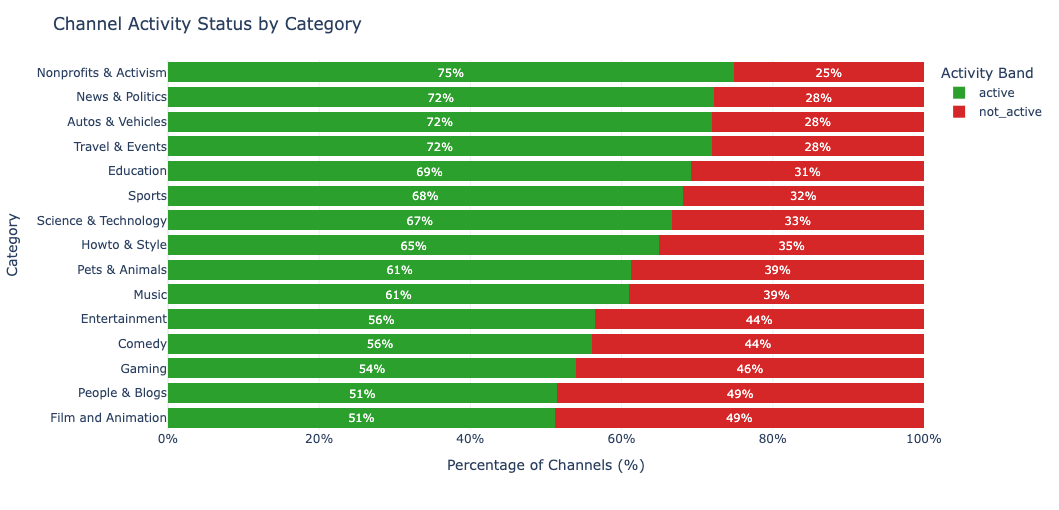

In [7]:
BAND_ORDER = ["active", "not_active"]

COLOR_MAP = {
    "active": "#2ca02c",
    "not_active": "#d62728"}

df_plot = df[df["category_cc"].notna()].copy()
if "activity_band_2025" not in df_plot.columns and "activity_band" in df_plot.columns:
    df_plot["activity_band_2025"] = df_plot["activity_band"]

df_plot["activity_band_2025"] = (
    df_plot["activity_band_2025"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "inactive": "not_active",
        "not active": "not_active",
        "notavailable": "not_active",
        "not available": "not_active",
        "no data available": "not_active",
        "nan": "not_active",
        "none": "not_active",
    })
)

df_plot.loc[~df_plot["activity_band_2025"].isin(BAND_ORDER), "activity_band_2025"] = "no_data_available"

sizes = df_plot["category_cc"].value_counts()
counts = (
    df_plot.groupby(["category_cc", "activity_band_2025"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=BAND_ORDER, fill_value=0)
)

pct = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100
order_cats = pct.sort_values(by="active", ascending=False).index.tolist()
long = (
    pct.reset_index()
    .melt(id_vars="category_cc", var_name="band", value_name="pct")
    .merge(
        counts.reset_index().melt(id_vars="category_cc", var_name="band", value_name="count"),
        on=["category_cc", "band"],
        how="left",
    )
)

long["band"] = pd.Categorical(long["band"], categories=BAND_ORDER, ordered=True)
long["category_cc"] = pd.Categorical(long["category_cc"], categories=order_cats, ordered=True)

long["label"] = long["pct"].apply(lambda v: f"{v:.0f}%" if v >= 4 else "")

fig = px.bar(
    long,
    x="pct",
    y="category_cc",
    color="band",
    orientation="h",
    category_orders={"category_cc": order_cats, "band": BAND_ORDER},
    color_discrete_map=COLOR_MAP,
    text="label",
    custom_data=["band", "count"],
)

fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Band: %{customdata[0]}<br>Percent: %{x:.1f}%<br>Count: %{customdata[1]:,}<extra></extra>",
    textposition="inside",
    insidetextanchor="middle",
    marker_line_width=0,
)

fig.update_layout(
    barmode="stack",
    title="Channel Activity Status by Category",
    xaxis_title="Percentage of Channels (%)",
    yaxis_title="Category",
    xaxis=dict(range=[0, 100], ticksuffix="%"),
    legend_title_text="Activity Band",
    template="plotly_white",
    height=max(420, 26 * len(order_cats) + 120),
)

fig.show()

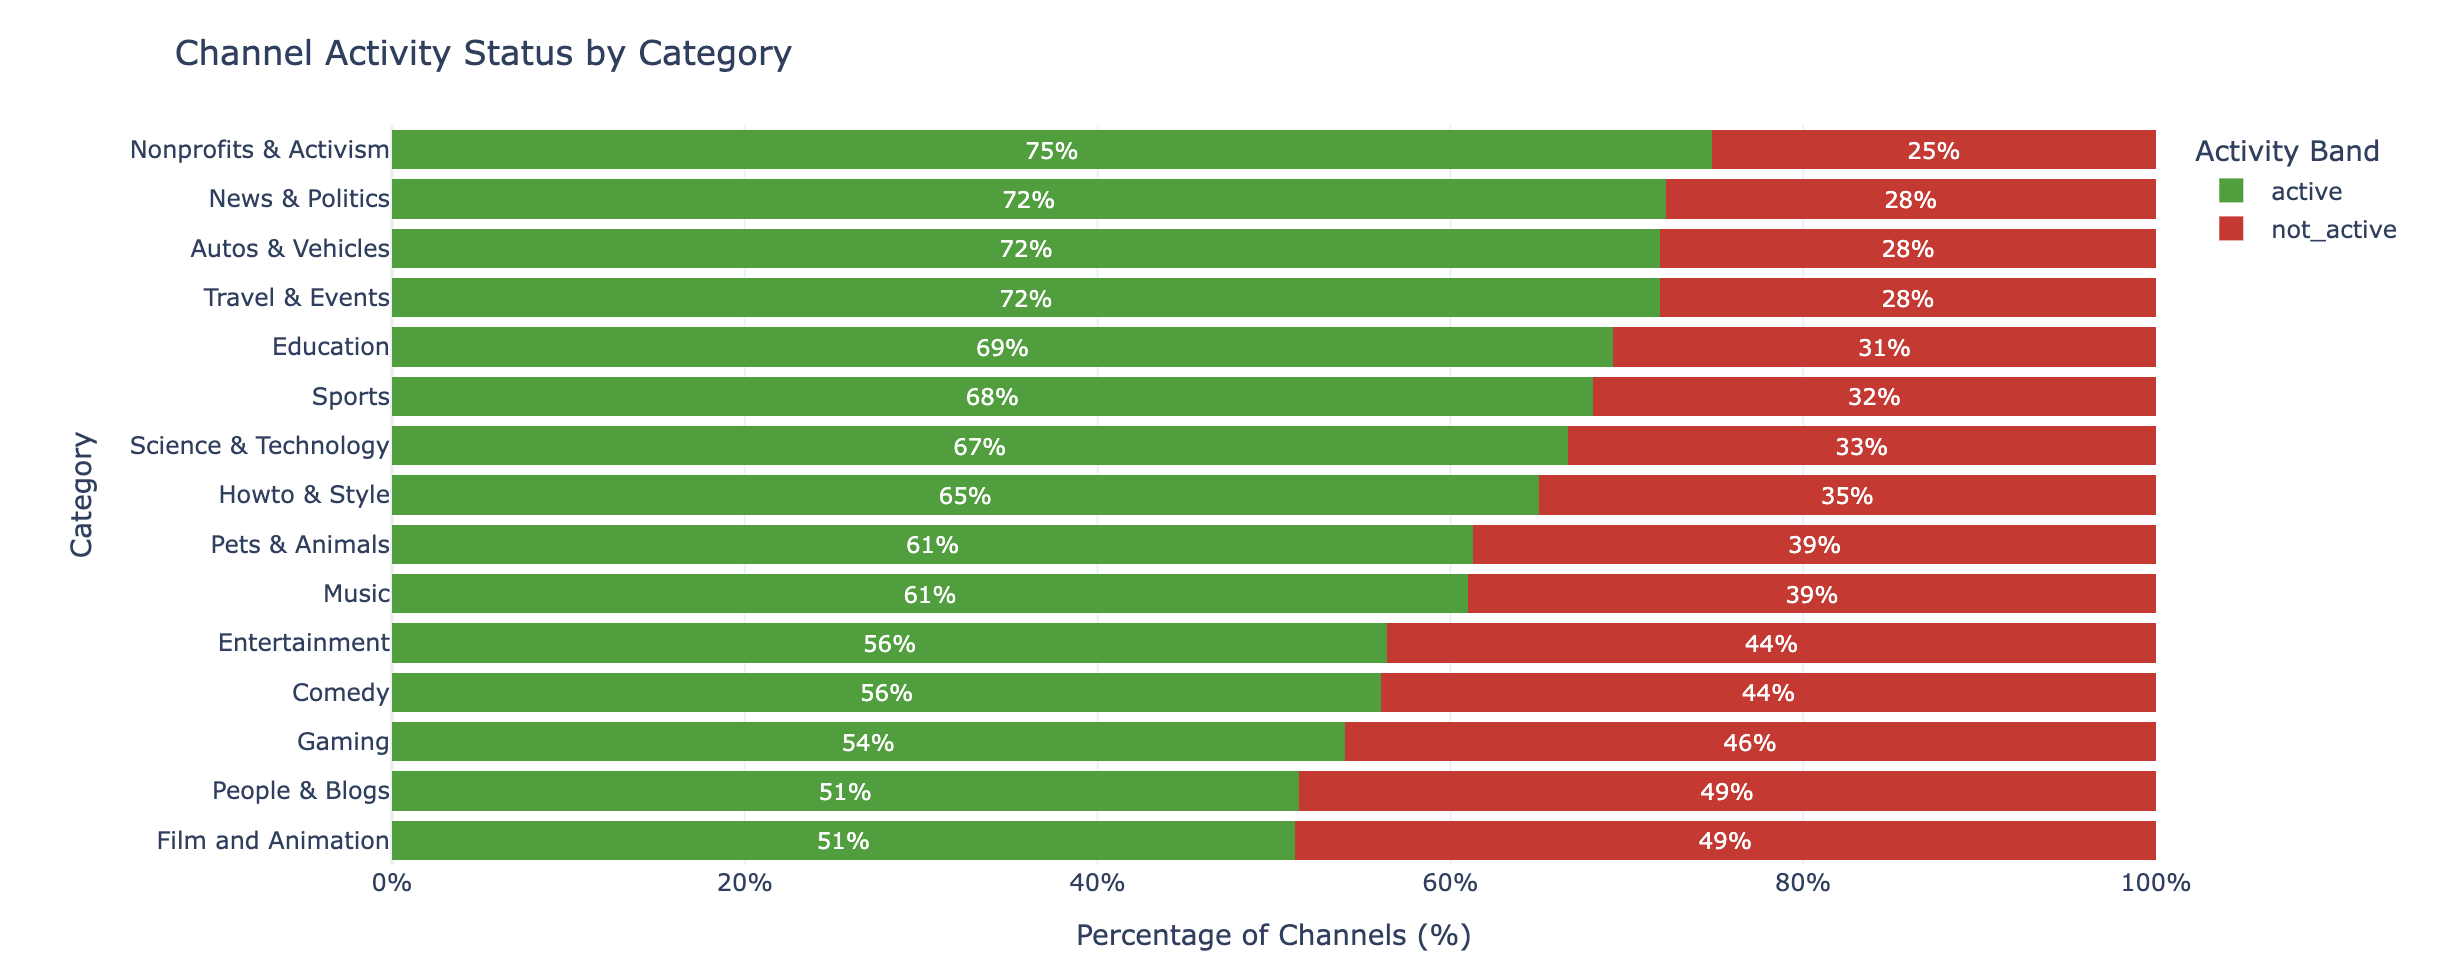

In [4]:
display(Image(filename="images/sample_plot_api.png"))

## Category Activity Aggregation and Sampling

This section prepares a compact JSON configuration for a category-level visualization of YouTube channel activity.

Starting from the API-enriched channel-level dataframe (`df_extended`), the goal is to produce:
- Per-category counts of **Active** vs **Not Active** channels  
- Representative channel links for each category and activity band  
- A lightweight JSON file ready for frontend consumption

This step bridges the gap between channel-level enrichment and category-level website visualizations.

## Configuration

- **`UNIT = 200`**  
  Defines the visual scale of the visualization. One icon represents approximately 200 channels.

- **`OUT_JSON`**  
  Output filename for the generated JSON configuration.

## Required Inputs

The pipeline expects a pandas dataframe `df_extended` containing the following fields:

- `category_cc` — Category used for grouping  
- `activity_band` or `activity_band_2025` — Channel activity label  
- `url` — Canonical channel URL  
- `subscribers_cc` — Subscriber count used for representative sampling  

Execution stops if any required field is missing to ensure data integrity.

## Preprocessing

Before aggregation, the data is standardized:

- The dataframe is copied to avoid mutating the original input  
- Activity labels are normalized to lowercase and harmonized  
- Subscriber counts are converted to numeric values, with missing values filled as 0  

This ensures stable grouping, sorting, and reproducible results.

## Category-Level Aggregation

For each category:

- Channels are grouped by `category_cc`  
- Counts of **Active** and **Not Active** channels are computed  

These aggregated counts form the quantitative backbone of the visualization.

## Representative Channel Sampling

To support interactive exploration in the frontend:

- Channel counts are scaled using `round(count / UNIT)`  
- For each activity band:
  - Channels are sorted by subscriber count (descending)  
  - Top channels are selected as representatives  
  - Relevant metadata fields are attached to each sampled channel  

Each visual icon therefore corresponds to a real YouTube channel rather than an abstract count.

## Output Structure

The exported JSON contains two main sections:

- **`DATA`** — Category-level summaries of channel activity  
- **`LINKS`** — Representative channel entries per category and activity band  

Categories are ordered by total size to improve visual readability.

## Export

The final configuration is written as a formatted JSON file and can be loaded directly by the website’s visualization layer without additional preprocessing.


In [8]:
OUT_JSON = "data/data_config_activity_v2_enriched_live.json"

df2 = normalize_activity_band(df_extended)
validate_activity_inputs(df2)

df2["subscribers_cc"] = pd.to_numeric(
    df2["subscribers_cc"], errors="coerce"
).fillna(0)

entries = []
for cat_label, df_cat in df2.groupby("category_cc", dropna=False):
    data_entry = make_category_counts(df_cat, cat_label, cat_label)
    links_entry = sample_representative_links(
        df_cat,
        unit=200,
        keep_fields=df2.columns.tolist(),
    )
    total = data_entry["active"] + data_entry["not_active"]
    entries.append((total, data_entry, links_entry))

entries.sort(key=lambda x: x[0], reverse=True)

DATA = [e[1] for e in entries]
LINKS = {e[1]["id"]: e[2] for e in entries}

config = {"DATA": DATA, "LINKS": LINKS}

with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print(f"wrote {OUT_JSON} | categories={len(DATA)}")

wrote data/data_config_activity_v2_enriched_live.json | categories=16


### Building the Website-Ready JSON (Category Activity)

This step converts the API-enriched channel table (`df_extended`) into a compact JSON configuration used by the website visualization.

The pipeline:
- normalizes activity labels and validates required fields,
- converts subscriber counts to numeric values for ranking,
- aggregates **Active** vs **Not Active** counts per category,
- samples representative channel links per category and activity band (scaled by `unit=200`),
- sorts categories by total size for clearer presentation,
- exports a single JSON file containing:
  - `DATA`: category-level activity counts
  - `LINKS`: representative channels for interactive inspection

The resulting configuration is written to `data_config_activity_v2_enriched_live.json` and can be loaded directly by the frontend.

Below, a small preview of the generated JSON is shown to illustrate its structure.  
The full configuration is written to disk and consumed directly by the website.

In [9]:
DATA[:3]

[{'id': 'Music', 'label': 'Music', 'active': 14816, 'not_active': 8077},
 {'id': 'Entertainment',
  'label': 'Entertainment',
  'active': 12950,
  'not_active': 7848},
 {'id': 'Gaming', 'label': 'Gaming', 'active': 10877, 'not_active': 7655}]

In [10]:
{
    "Music": {
        "active": LINKS["Music"]["active"][:2]
    }
}

{'Music': {'active': [{'category_cc': 'Music',
    'join_date': '2006-03-13',
    'channel': 'UCq-Fj5jknLsUf-MWSy4_brA',
    'name_cc': 'T-Series',
    'subscribers_cc': 112139463,
    'videos_cc': 13839,
    'subscriber_rank_sb': 102.0,
    'weights': 2.0869999999999997,
    '_channel_id_norm': 'UCq-Fj5jknLsUf-MWSy4_brA',
    'url': 'https://www.youtube.com/channel/UCq-Fj5jknLsUf-MWSy4_brA',
    'has_api': True,
    'subs_fetched_at_utc': '2025-12-15T12:11:35.874110+00:00',
    'channel_title_2025': 'T-Series',
    'channel_avatar_url_2025': 'https://yt3.ggpht.com/VunTf0NzCeboiPjbesBdnQuxaF3Lja7UGRbBGQAWRJgMSTj9TTLO3pS1X9qPOJGCNnmPrXeY=s800-c-k-c0x00ffffff-no-rj',
    'subscriber_count_2025': '308000000.0',
    'video_count_2025': '24985.0',
    'view_count_2025': '323166782568.0',
    'uploads_playlist_id': 'UUq-Fj5jknLsUf-MWSy4_brA',
    'latest_video_id': 'OBLQTYgCaDo',
    'last_upload_utc_2025': '2025-12-15T11:28:12Z',
    'last_video_title_2025': 'Maa Ka Darbaar (Audio): Sonu Ni